In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
import re

def clean(string):
  return re.sub(r'[^0-9.]', '', string)

def read_logfile(filepath):
  batches = []
  ctc_losses = []
  cers = []
  time_batches = []

  with open(filepath, "r") as file:
    for line in file:
        line = line.strip()
        lines = line.split(",")

        batches.append(int(clean(lines[0])))
        ctc_losses.append(float(clean(lines[1])))
        cers.append(float(clean(lines[2])))
        time_batches.append(float(clean(lines[3])))

  df = pd.DataFrame()
  df["batch"] = batches
  df["ctc_loss"] = ctc_losses
  df["cer"] = cers
  df["time_batch"] = time_batches

  return df

base_df = read_logfile("training_logs/baseline.log")
adamW_df = read_logfile("training_logs/adamW.log")
NAG_df = read_logfile("training_logs/NAG.log")
batchconv_df = read_logfile("training_logs/batchnorm_convolution_10000.log")

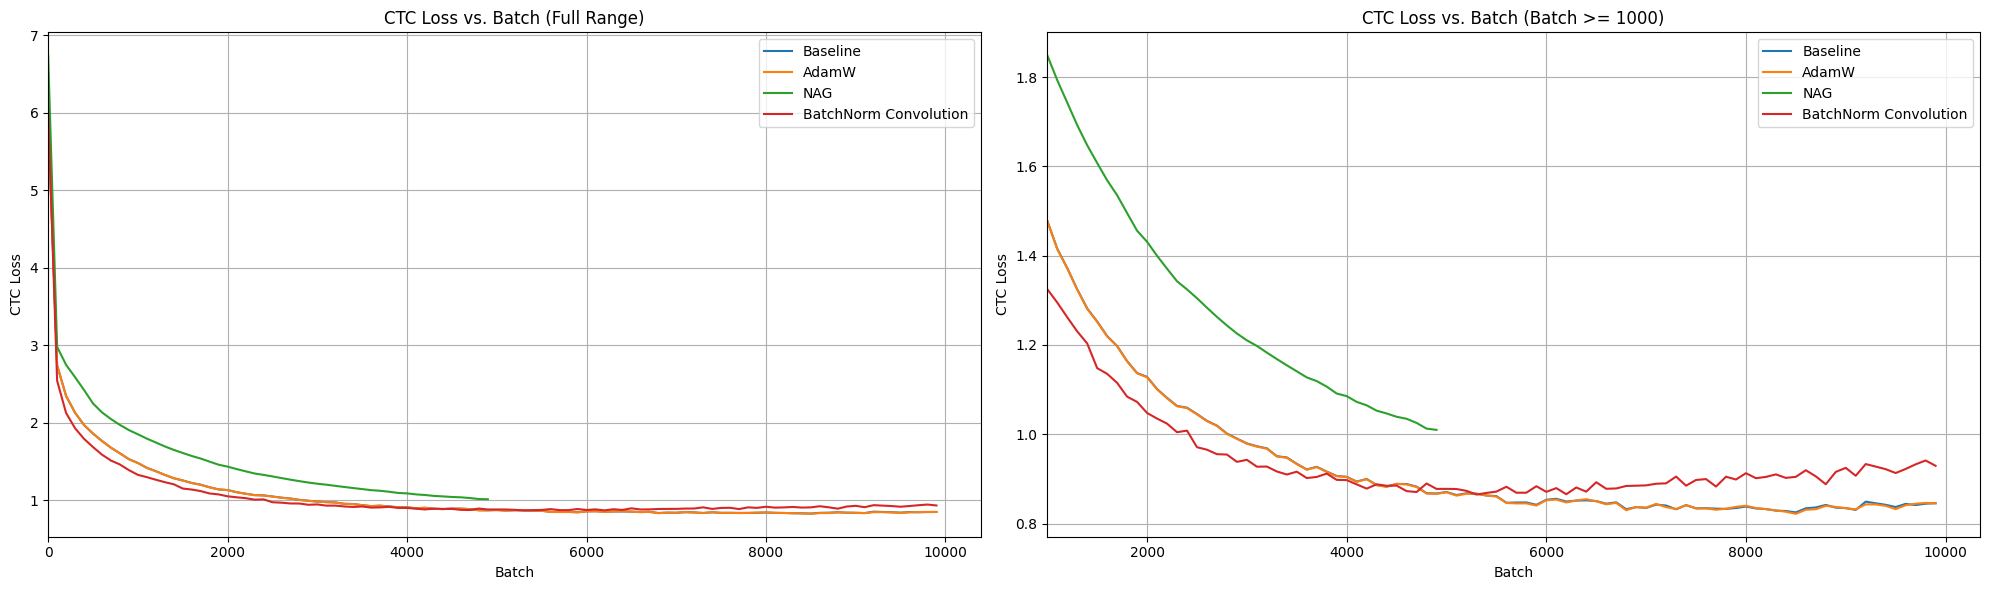

In [ ]:
plt.figure(figsize=(20, 6)) # Increase figure size to accommodate two subplots

# First subplot: Full range
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(base_df['batch'], base_df['ctc_loss'], label='Baseline')
plt.plot(adamW_df['batch'], adamW_df['ctc_loss'], label='AdamW')
plt.plot(NAG_df['batch'], NAG_df['ctc_loss'], label='NAG')
plt.plot(batchconv_df['batch'], batchconv_df['ctc_loss'], label='BatchNorm Convolution')
plt.xlabel('Batch')
plt.ylabel('CTC Loss')
plt.title('CTC Loss vs. Batch (Full Range)')
plt.legend()
plt.grid(True)
plt.xlim(left=0)

# Filter dataframes for batch >= 1000
base_df_filtered = base_df[base_df['batch'] >= 1000]
adamW_df_filtered = adamW_df[adamW_df['batch'] >= 1000]
NAG_df_filtered = NAG_df[NAG_df['batch'] >= 1000]
batchconv_df_filtered = batchconv_df[batchconv_df['batch'] >= 1000]

# Second subplot: Batch >= 1000
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(base_df_filtered['batch'], base_df_filtered['ctc_loss'], label='Baseline')
plt.plot(adamW_df_filtered['batch'], adamW_df_filtered['ctc_loss'], label='AdamW')
plt.plot(NAG_df_filtered['batch'], NAG_df_filtered['ctc_loss'], label='NAG')
plt.plot(batchconv_df_filtered['batch'], batchconv_df_filtered['ctc_loss'], label='BatchNorm Convolution')
plt.xlabel('Batch')
plt.ylabel('CTC Loss')
plt.title('CTC Loss vs. Batch (Batch >= 1000)')
plt.legend()
plt.grid(True)
plt.xlim(left=1000) # Set the x-axis lower limit to 1000

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

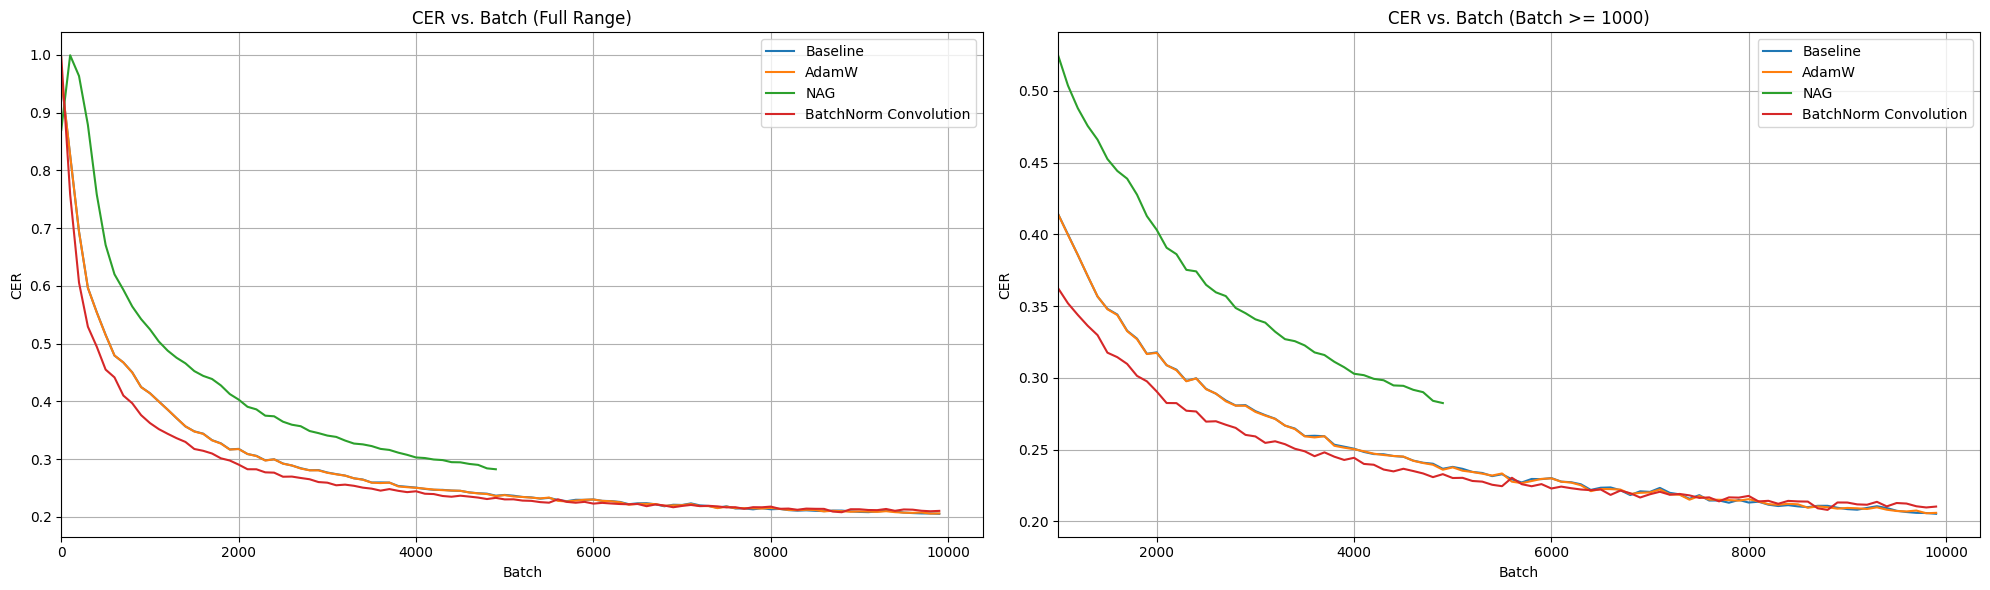

In [ ]:
plt.figure(figsize=(20, 6)) # Increase figure size to accommodate two subplots

# First subplot: Full range
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(base_df['batch'], base_df['cer'], label='Baseline')
plt.plot(adamW_df['batch'], adamW_df['cer'], label='AdamW')
plt.plot(NAG_df['batch'], NAG_df['cer'], label='NAG')
plt.plot(batchconv_df['batch'], batchconv_df['cer'], label='BatchNorm Convolution')
plt.xlabel('Batch')
plt.ylabel('CER')
plt.title('CER vs. Batch (Full Range)')
plt.legend()
plt.grid(True)
plt.xlim(left=0)

# Filter dataframes for batch >= 1000
base_df_filtered = base_df[base_df['batch'] >= 1000]
adamW_df_filtered = adamW_df[adamW_df['batch'] >= 1000]
NAG_df_filtered = NAG_df[NAG_df['batch'] >= 1000]
batchconv_df_filtered = batchconv_df[batchconv_df['batch'] >= 1000]

# Second subplot: Batch >= 1000
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(base_df_filtered['batch'], base_df_filtered['cer'], label='Baseline')
plt.plot(adamW_df_filtered['batch'], adamW_df_filtered['cer'], label='AdamW')
plt.plot(NAG_df_filtered['batch'], NAG_df_filtered['cer'], label='NAG')
plt.plot(batchconv_df_filtered['batch'], batchconv_df_filtered['cer'], label='BatchNorm Convolution')
plt.xlabel('Batch')
plt.ylabel('CER')
plt.title('CER vs. Batch (Batch >= 1000)')
plt.legend()
plt.grid(True)
plt.xlim(left=1000) # Set the x-axis lower limit to 1000

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

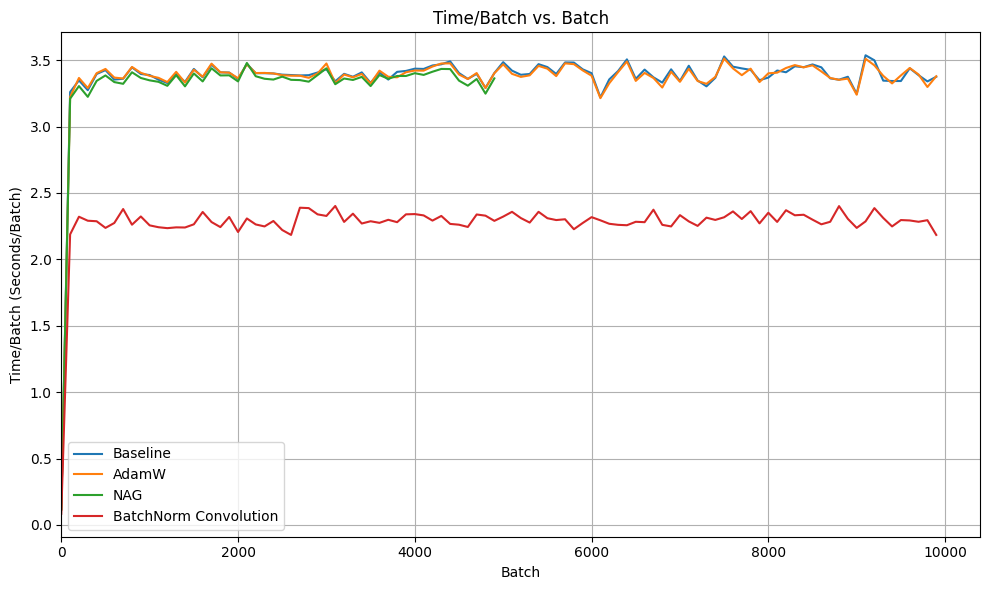

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(base_df['batch'], base_df['time_batch'], label='Baseline')
plt.plot(adamW_df['batch'], adamW_df['time_batch'], label='AdamW')
plt.plot(NAG_df['batch'], NAG_df['time_batch'], label='NAG')
plt.plot(batchconv_df['batch'], batchconv_df['time_batch'], label='BatchNorm Convolution')
plt.xlabel('Batch')
plt.ylabel('Time/Batch (Seconds/Batch)')
plt.title('Time/Batch vs. Batch')
plt.legend()
plt.grid(True)
plt.xlim(left=0)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [ ]:
dataframes = {
    'Baseline': base_df,
    'AdamW': adamW_df,
    'NAG': NAG_df,
    'BatchNorm Convolution': batchconv_df
}

metrics = ['cer', 'ctc_loss']

for name, df in dataframes.items():
    print(f"\n--- {name} ---")
    for metric in metrics:
        min_value = df[metric].min()
        min_batch = df.loc[df[metric].idxmin(), 'batch']
        print(f"Minimum {metric.upper()}: {min_value:.6f} at Batch: {min_batch}")


--- Baseline ---
Minimum CER: 0.205316 at Batch: 9900
Minimum CTC_LOSS: 0.825029 at Batch: 8500

--- AdamW ---
Minimum CER: 0.205687 at Batch: 9800
Minimum CTC_LOSS: 0.821890 at Batch: 8500

--- NAG ---
Minimum CER: 0.282448 at Batch: 4900
Minimum CTC_LOSS: 1.009815 at Batch: 4900

--- BatchNorm Convolution ---
Minimum CER: 0.208039 at Batch: 8800
Minimum CTC_LOSS: 0.864987 at Batch: 5300
